── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘cowplot’


The following object is masked from ‘package:lubridate’:

    stamp



Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




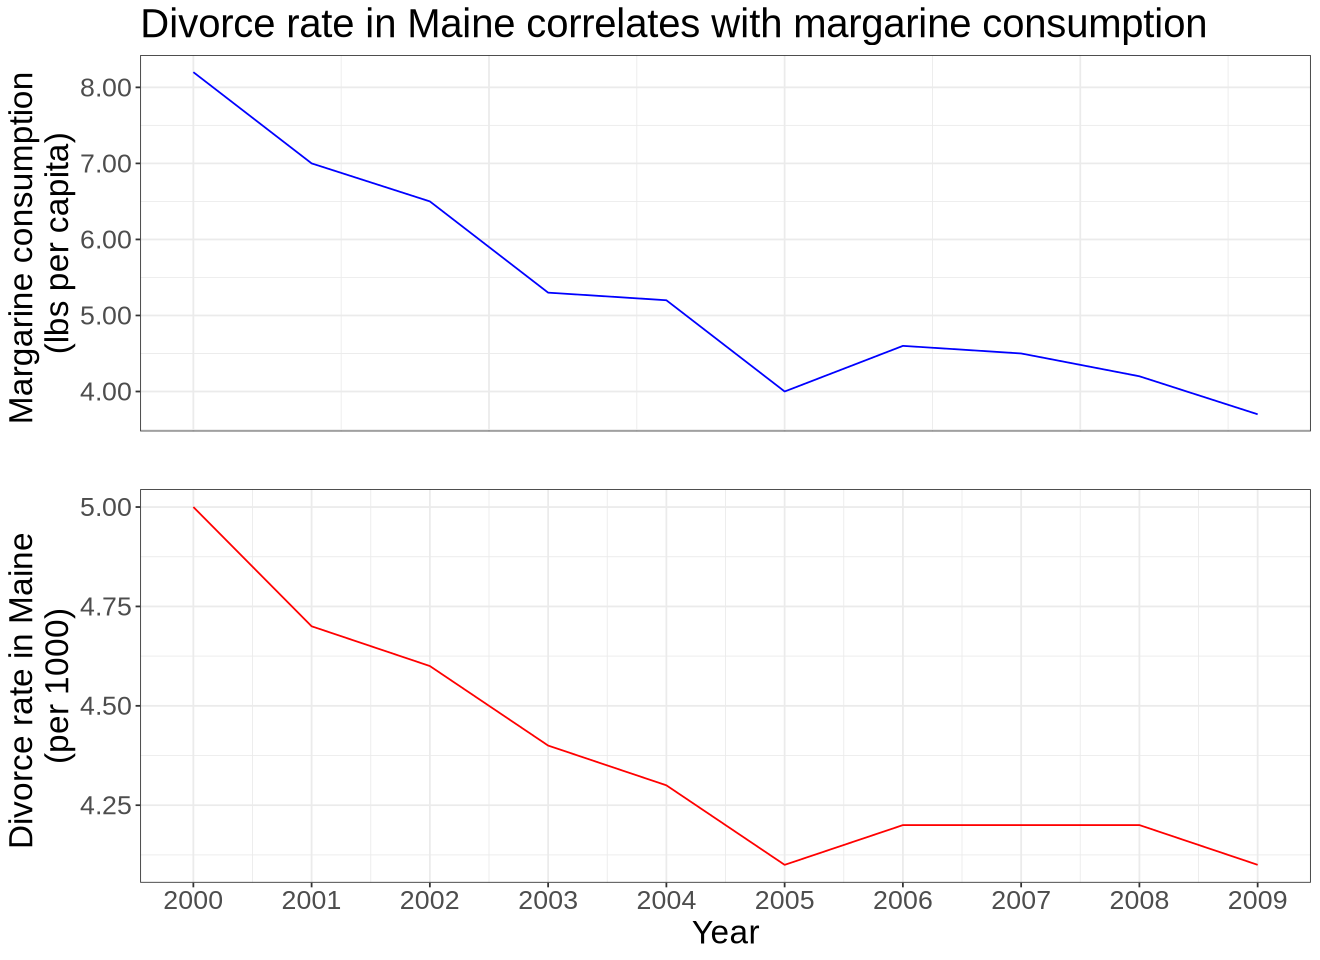

In [2]:
library(tidyverse)
library(cowplot)
library(scales)

# Data sourced from the Spurious Correlations website (http://www.tylervigen.com/spurious-correlations)
should_have_bought_butter <- tibble(margarine_consumption = c(8.2, 7, 6.5, 5.3, 5.2,
                                                             4, 4.6, 4.5, 4.2, 3.7),
                                   maine_divorce_rate = c(5, 4.7, 4.6, 4.4, 4.3,
                                                         4.1, 4.2, 4.2, 4.2, 4.1),
                                   year = c(2000, 2001, 2002, 2003, 2004,
                                           2005, 2006, 2007, 2008, 2009))

marg_vs_time <- should_have_bought_butter |> 
    ggplot(aes(x = year, y = margarine_consumption)) +
        geom_line(colour = "Blue") + 
        labs(x = "", y = "Margarine consumption \n(lbs per capita)", 
             title = "Divorce rate in Maine correlates with margarine consumption") +
        theme_bw() +
        theme(axis.ticks.x = element_blank(),
        axis.text.x = element_blank()) +
        theme(text = element_text(size = 20)) +
        scale_y_continuous(labels = number_format(accuracy = 0.01))


divorce_rate_vs_time <- should_have_bought_butter |> 
    ggplot(aes(x = year, y = maine_divorce_rate)) +
        geom_line(colour = "Red") + 
        labs(x = "Year", y = "Divorce rate in Maine \n(per 1000)") +
        scale_x_continuous(breaks = 0:2100) +
        theme_bw() +
        theme(text = element_text(size = 20)) 

options(repr.plot.width = 11, repr.plot.height = 8)
plot_grid(marg_vs_time, divorce_rate_vs_time, ncol = 1)

In [54]:

if (!requireNamespace("dslabs", quietly = TRUE)) {
  install.packages("dslabs")
}

library(dslabs)
library(tidyverse)

data("divorce_margarine")

divorce_margarine|> 
  head(6)


,divorce_rate_maine,margarine_consumption_per_capita,year
,<dbl>,<dbl>,<int>
1,5.0,8.2,2000
2,4.7,7.0,2001
3,4.6,6.5,2002
4,4.4,5.3,2003
5,4.3,5.2,2004
6,4.1,4.0,2005


Is there a correlation between margarine consumption and divorce rate in Maine from 2000 to 2009?

Descriptive question since we are asking whether the two measured variables have a correlation.

In [55]:
library(dslabs)
library(tidyverse)

data("divorce_margarine") #loaded the divorce_margarine dataset

#renamed the columns
tidy_divorce_margarine <- divorce_margarine |>
    rename(
    year = year,
    margarine = margarine_consumption_per_capita,
    divorce = divorce_rate_maine) |>
    arrange(year) |>
    distinct() |>
    drop_na() |>
    mutate(
    year = as.integer(year),
    period = case_when(
      year <= 2003 ~ "Early (2000-2003)",
      year <= 2006 ~ "Mid (2004-2006)",
      TRUE         ~ "Late (2007-2009)"
    )
  )

tidy_divorce_margarine
head(6)

divorce,margarine,year,period
<dbl>,<dbl>,<int>,<chr>
5.0,8.2,2000,Early (2000-2003)
4.7,7.0,2001,Early (2000-2003)
4.6,6.5,2002,Early (2000-2003)
4.4,5.3,2003,Early (2000-2003)
4.3,5.2,2004,Mid (2004-2006)
4.1,4.0,2005,Mid (2004-2006)
4.2,4.6,2006,Mid (2004-2006)
4.2,4.5,2007,Late (2007-2009)
4.2,4.2,2008,Late (2007-2009)


[1] 6

In [56]:
stats <- tidy_divorce_margarine |>
  summarize(across(where(is.numeric), list(mean = mean, min = min, max = max), na.rm = TRUE))

stats

divorce_mean,divorce_min,divorce_max,margarine_mean,margarine_min,margarine_max,year_mean,year_min,year_max
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
4.38,4.1,5,5.32,3.7,8.2,2004.5,2000,2009


In [57]:
missing_stats <- tidy_divorce_margarine |>
  summarize(across(everything(), ~ sum(is.na(.)))) |>
  pivot_longer(everything(), names_to = "variable", values_to = "missing_count")

missing_stats

variable,missing_count
<chr>,<int>
divorce,0
margarine,0
year,0
period,0


In [58]:
group_summary <- tidy_divorce_margarine |>
  group_by(period) |>
  summarize(
    margarine_mean = mean(margarine, na.rm = TRUE),
    margarine_min = min(margarine, na.rm = TRUE),
    margarine_max = max(margarine, na.rm = TRUE),
    divorce_mean = mean(divorce, na.rm = TRUE),
    divorce_min  = min(divorce,na.rm = TRUE),
    divorce_max  = max(divorce, na.rm = TRUE)
  )

group_summary

period,margarine_mean,margarine_min,margarine_max,divorce_mean,divorce_min,divorce_max
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Early (2000-2003),6.750000,5.3,8.2,4.675000,4.4,5.0
Late (2007-2009),4.133333,3.7,4.5,4.166667,4.1,4.2
Mid (2004-2006),4.600000,4.0,5.2,4.200000,4.1,4.3


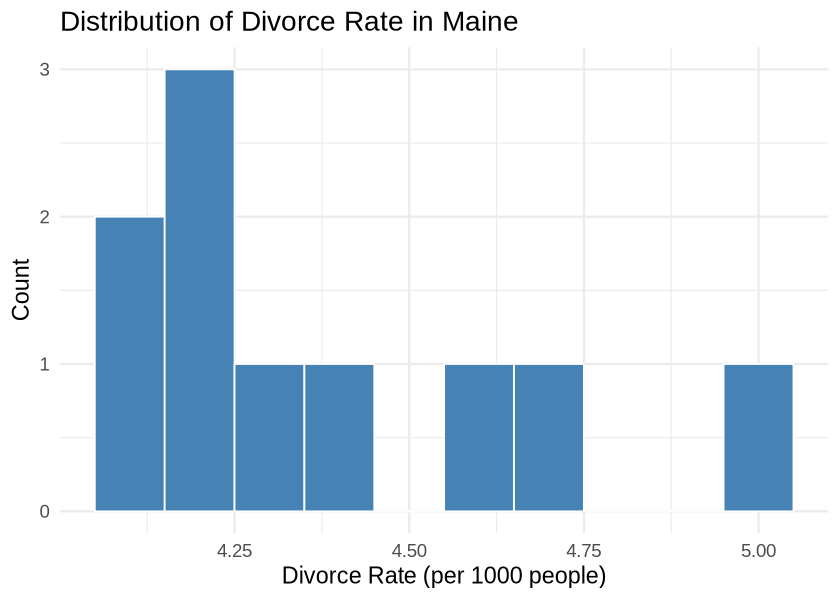

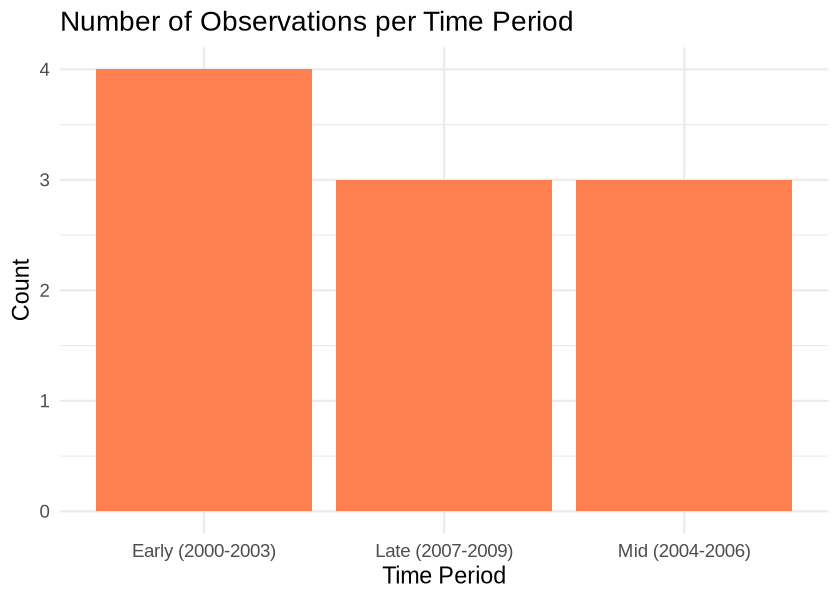

In [59]:
options(repr.plot.height = 5, repr.plot.width = 7)

# Plot 1: Distribution of numeric variable (divorce rate)
divorce_plot <- ggplot(tidy_divorce_margarine, aes(x = divorce)) +
  geom_histogram(bins = 10, fill = "steelblue", color = "white") +
  labs(title = "Distribution of Divorce Rate in Maine",
       x = "Divorce Rate (per 1000 people)",
       y = "Count") +
  theme_minimal(base_size = 14)
divorce_plot

# Plot 2: Relative proportions of categorical variable (period)
margarine_plot <- ggplot(tidy_divorce_margarine, aes(x = period)) +
  geom_bar(fill = "coral") +
  labs(title = "Number of Observations per Time Period",
       x = "Time Period",
       y = "Count") +
  theme_minimal(base_size = 14)
margarine_plot

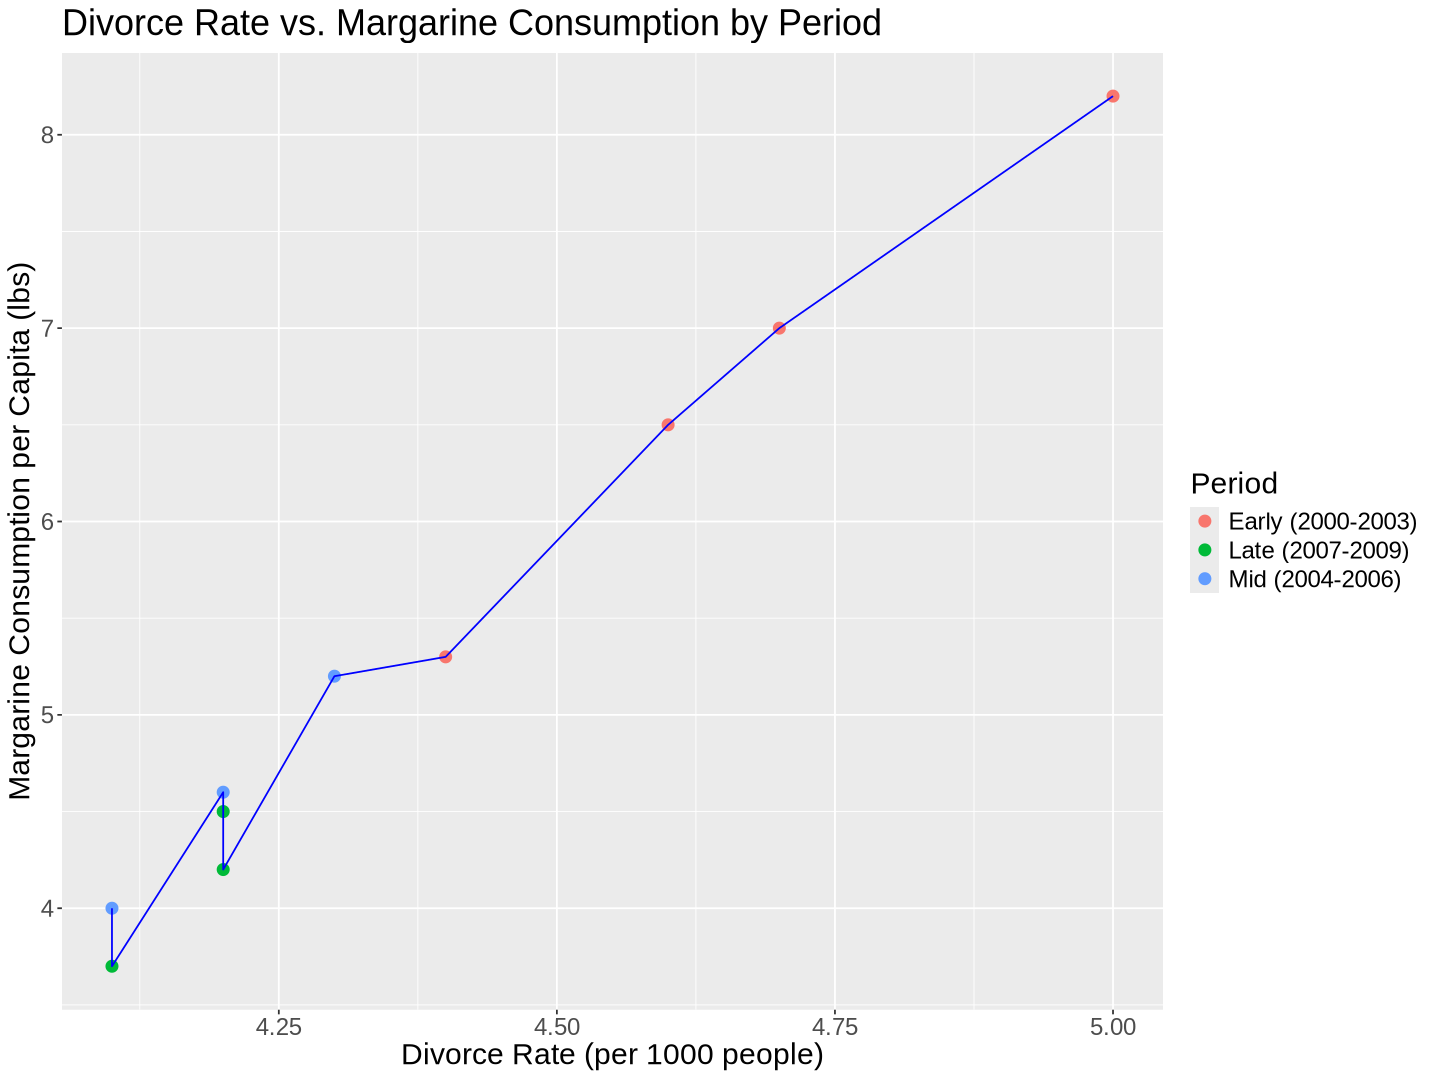

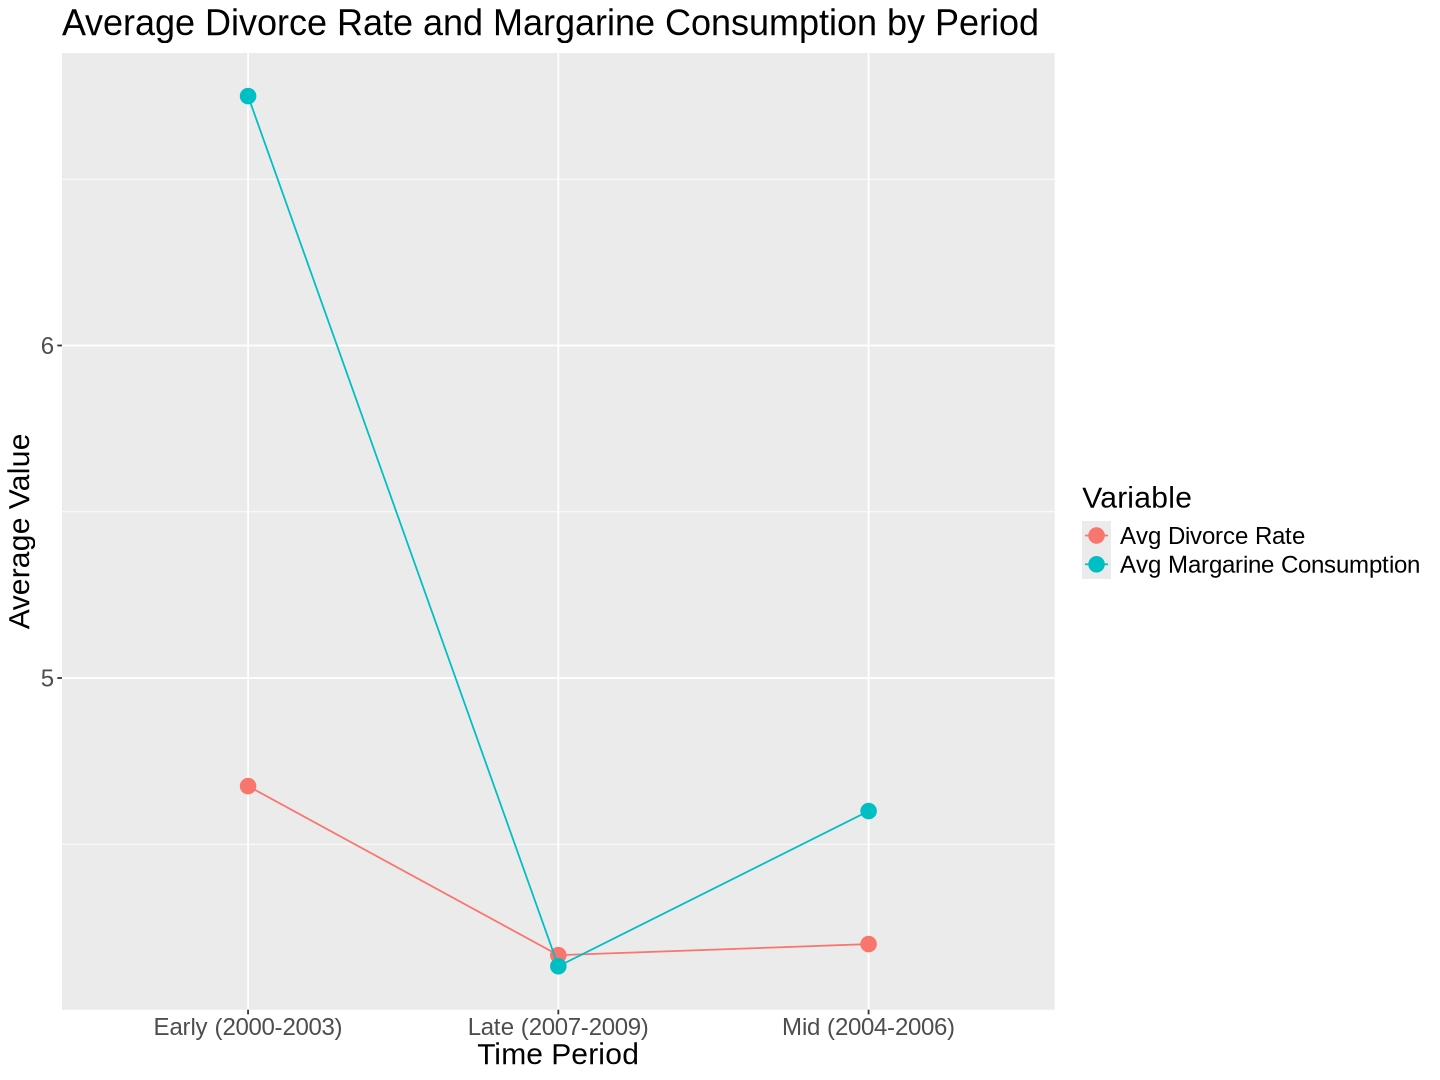

In [71]:
options(repr.plot.height = 9, repr.plot.width = 12)

# Plot 1: Scatter with line — divorce vs margarine, colored by period
scatter_plot <- ggplot(tidy_divorce_margarine, aes(x = divorce, y = margarine,color = period)) +
  geom_point(size = 3) +
  geom_line(color = "blue") +
  labs(title = "Divorce Rate vs. Margarine Consumption by Period",
       x = "Divorce Rate (per 1000 people)",
       y = "Margarine Consumption per Capita (lbs)",
       color = "Period") +
  theme(text=element_text(size = 18))
scatter_plot

# Plot 2: Average divorce and margarine over time per period
time_plot <- ggplot(group_summary, aes(x = period, group = 1)) +
  geom_point(aes(y = divorce_mean, color = "Avg Divorce Rate"), size = 4) +
  geom_line(aes(y = divorce_mean, color = "Avg Divorce Rate")) +
  geom_point(aes(y = margarine_mean, color = "Avg Margarine Consumption"), size = 4) +
  geom_line(aes(y = margarine_mean, color = "Avg Margarine Consumption")) +
  labs(title = "Average Divorce Rate and Margarine Consumption by Period",
       x = "Time Period",
       y = "Average Value",
       color = "Variable") +
  theme(text=element_text(size = 18))
time_plot